# ARIMA and Friends: Modelling the Memory of a Series

**DCS 404 · Data Science and Machine Learning**

---

Module 10 taught us to *diagnose* a time series — decompose it, difference it to stationarity, and read
its ACF/PACF fingerprint. Module 11 gave us our first real forecasting family, exponential smoothing,
which builds a forecast out of weighted averages of the recent past.

This module completes the classical toolkit with the family that has dominated academic time series
analysis since Box and Jenkins published their methodology in 1970: **ARIMA**. Where exponential smoothing
describes a series through *components* (level, trend, season), ARIMA describes it through
**autocorrelation** — the explicit statement that today's value is a linear function of specific past
values and specific past shocks.

The name is an acronym assembled from three ideas we will build one at a time:

- **AR** — *AutoRegressive*: regress the series on **its own past values**.
- **I** — *Integrated*: the differencing from Module 10, folded into the model as a parameter.
- **MA** — *Moving Average*: regress the series on **its own past forecast errors**. (Nothing to do with
  the rolling means of Module 10 — an unfortunate but universal collision of terminology.)

Bolt on seasonal versions of all three and you get **SARIMA**; add external predictors and you get
**SARIMAX**. That single expandable model covers most of what classical forecasting does.

The Box-Jenkins promise is that model *identification* is a readable procedure rather than a guess: make
the series stationary, read the orders off the correlogram, fit, then check that the residuals are white
noise. By the end of this module we will run that procedure on the Air Passengers series and watch it
rediscover — from the data alone — the specific model Box and Jenkins made famous with it.

## How to work through this

The usual rhythm: run every code cell (`Shift + Enter`), study the output, *then* read the commentary.
Cells build on each other, so if something errors, run from the top.

The module is in four acts:

1. **Sections 1–2** set up the notation (the backshift operator) and the strategy.
2. **Sections 3–5** build the model from parts on *synthetic data where we know the true answer*: **AR**,
   **MA**, then **ARMA**. Simulating series with known parameters is the only honest way to learn
   identification — on real data you never find out whether you were right.
3. **Sections 6–8** handle real data: **ARIMA** for trend, order selection by **AIC/BIC**, and **SARIMA**
   for seasonality.
4. **Sections 9–11** finish the job: **residual diagnostics** (the step everyone skips), a full
   end-to-end forecast of Air Passengers scored against every baseline from Modules 10 and 11, and
   **SARIMAX** for external predictors.

> **A note on the API.** Much older material — including many textbooks and tutorials still online — uses
> `sm.tsa.ARMA`, `model.plot_predict()` and `fit(trend='nc', disp=-1)`. All of that was **removed** from
> statsmodels. The modern entry points are `statsmodels.tsa.arima.model.ARIMA` and
> `statsmodels.tsa.statespace.sarimax.SARIMAX`, which is what we use throughout.

## Learning objectives

After completing this module you will be able to:

- Write models compactly with the **backshift operator** $B$ and relate $\nabla^d$ to $(1-B)^d$.
- Define **AR(p)**, **MA(q)**, **ARMA(p,q)**, **ARIMA(p,d,q)** and **SARIMA$(p,d,q)(P,D,Q)_s$**, and
  state how each generalises the last.
- Use the **ACF/PACF cut-off rules** to propose candidate orders, and explain why they give only *upper
  bounds* for a mixed ARMA process.
- Simulate processes with `ArmaProcess` (including the **sign convention** that trips everyone up) and
  recover the true parameters by fitting.
- Select orders with **AIC** and **BIC** via a grid search, and explain the penalty each applies.
- Validate a fitted model with **residual diagnostics** — ACF, histogram, and the **Ljung-Box** test.
- Produce and back-transform a forecast with prediction intervals, and score it against baselines.
- Explain **endogenous vs exogenous** variables and fit a **SARIMAX** model with external regressors.

## Setup

Run this once. Libraries, plotting style, the Air Passengers series, and the metric functions from
Module 10 so we can compare like with like.

In [1]:
from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")   # ML optimisers grumble during grid searches

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def load_csv(name, **kwargs):
    for candidate in [Path(f"data/{name}"), Path(f"notebooks/data/{name}")]:
        if candidate.exists():
            print(f"Loaded {name} from: {candidate}")
            return pd.read_csv(candidate, **kwargs)
    raise FileNotFoundError(f"Could not find {name}")

air = load_csv("air_passengers.csv", parse_dates=["Month"], index_col="Month").asfreq("MS")
passengers = air["Passengers"]

# The same chronological split as Module 10, so every score is comparable
TEST_MONTHS = 24
train, test = passengers[:-TEST_MONTHS], passengers[-TEST_MONTHS:]

def mase(y_true, y_pred, y_train, m=12):
    """Mean Absolute Scaled Error: MAE relative to in-sample seasonal-naive MAE."""
    naive_mae = np.mean(np.abs(y_train[m:].values - y_train[:-m].values))
    return np.mean(np.abs(y_true - y_pred)) / naive_mae

def evaluate(y_true, y_pred, y_train, m=12):
    e = np.asarray(y_true) - np.asarray(y_pred)
    return {
        "MAE":  np.mean(np.abs(e)),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAPE": np.mean(np.abs(e / np.asarray(y_true))) * 100,
        "MASE": mase(np.asarray(y_true), np.asarray(y_pred), y_train, m),
    }

print(f"Train: {train.index.min():%b %Y} to {train.index.max():%b %Y}  ({len(train)} months)")
print(f"Test:  {test.index.min():%b %Y} to {test.index.max():%b %Y}  ({len(test)} months)")

Loaded air_passengers.csv from: data/air_passengers.csv
Train: Jan 1949 to Dec 1958  (120 months)
Test:  Jan 1959 to Dec 1960  (24 months)


---
## 1. The backshift operator

One piece of notation makes every formula in this module dramatically shorter, so we pay for it upfront.

The **backshift operator** $B$ shifts a series one step into the past:

$$B y_t = y_{t-1}, \qquad B^k y_t = y_{t-k}$$

It is `shift()` from Module 10, written as algebra. Its power is that it can be manipulated like an
ordinary variable. Differencing, for instance, becomes multiplication:

$$\nabla y_t = y_t - y_{t-1} = y_t - B y_t = (1 - B) y_t$$

so $d$-th order differencing is just $\nabla^d = (1-B)^d$, and seasonal differencing with period $s$ is
$\nabla_s = (1 - B^s)$. Expanding $(1-B)^2$ with ordinary algebra even gives the correct second
difference:

$$(1-B)^2 y_t = (1 - 2B + B^2)y_t = y_t - 2y_{t-1} + y_{t-2}$$

We will write **polynomials in $B$** to package a whole set of coefficients:

$$\phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \dots - \phi_p B^p \qquad\qquad
\theta(B) = 1 + \theta_1 B + \theta_2 B^2 + \dots + \theta_q B^q$$

Note the minus signs in $\phi(B)$ and the plus signs in $\theta(B)$. That asymmetry is a genuine
convention, not a typo, and it is the source of the most common bug in this entire topic — Section 3
shows exactly where it bites.

---
## 2. The strategy

Every model in this module is a variation on one sentence:

> **The current value is a linear combination of past values and past random shocks.**

Let $Z_t$ be **white noise** — the unforecastable innovations from Module 10, $Z_t \sim N(0, \sigma^2)$,
independent. The family is then organised by which ingredients are allowed:

| Model | Uses past **values**? | Uses past **shocks**? | Handles trend? | Handles season? |
|---|---|---|---|---|
| **AR(p)** | yes | no | no | no |
| **MA(q)** | no | yes | no | no |
| **ARMA(p,q)** | yes | yes | no | no |
| **ARIMA(p,d,q)** | yes | yes | yes (via $d$) | no |
| **SARIMA$(p,d,q)(P,D,Q)_s$** | yes | yes | yes | yes (via $D$, $P$, $Q$) |
| **SARIMAX** | yes | yes | yes | yes | *(plus external regressors)* |

Each row is strictly more general than the one above; every model is a special case of SARIMAX with some
orders set to zero. The **Box-Jenkins methodology** for choosing among them is a four-step loop, and it
structures the rest of this module:

1. **Identify** — transform to stationarity (Module 10), then read candidate orders off the ACF/PACF.
2. **Estimate** — fit the candidates by maximum likelihood.
3. **Check** — verify the residuals are white noise. *If they are not, return to step 1.*
4. **Forecast** — only once step 3 passes.

---
## 3. AR(p): regressing on the past

An **autoregressive** model of order $p$ predicts $y_t$ from its own $p$ previous values:

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + Z_t$$

or compactly, $\phi(B)\, y_t = c + Z_t$.

It is literally a linear regression whose predictors are lagged copies of the target — which is why
Module 10 spent time on `shift()`. AR(1) with $\phi_1 = 0.9$ describes a series with long memory that
drifts slowly back to its mean; with $\phi_1 = 0.2$ it snaps back almost immediately.

For an AR model to be **stationary** the $\phi$ coefficients are constrained. For AR(1) the condition is
simply $|\phi_1| < 1$: if $|\phi_1| > 1$ each value amplifies the last and the series explodes, and
$\phi_1 = 1$ gives a **random walk** — the unit root that the ADF test hunts for.

### Simulating: mind the sign convention

`ArmaProcess` expects the AR polynomial **as written in $\phi(B)$**, including its minus signs. So to
simulate $y_t = 0.6y_{t-1} + 0.25y_{t-2} + Z_t$ you must pass `[1, -0.6, -0.25]`, *negating* your
coefficients. Forgetting this is the classic error, and it silently produces a completely different
process rather than raising an error.

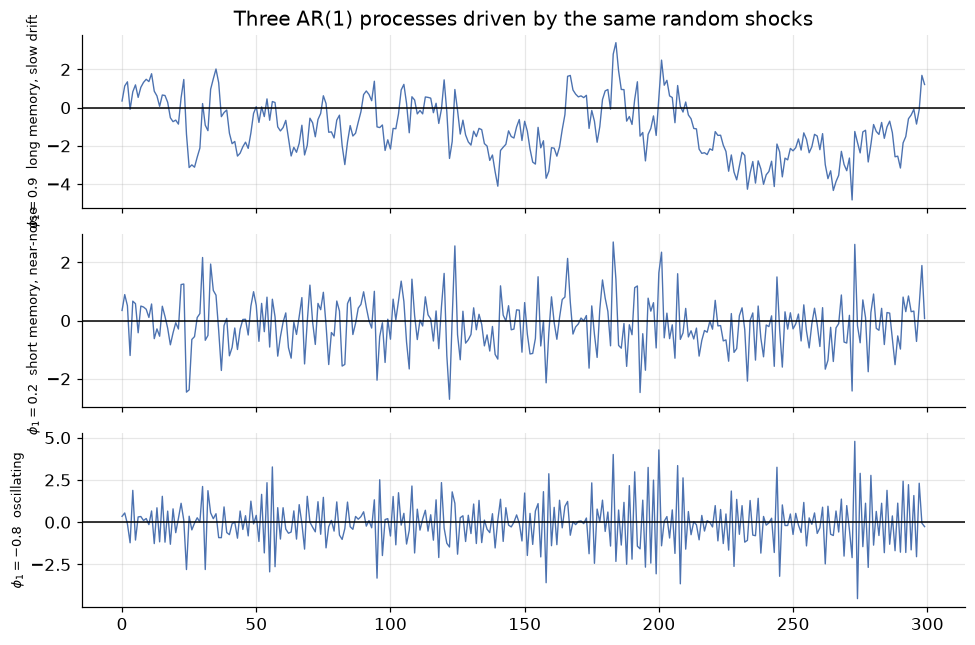

In [2]:
def simulate_arma(ar_params, ma_params, n, rng):
    """Simulate an ARMA series. Pass coefficients as they appear in the *model* equation;
    the sign flip required by ArmaProcess is handled here."""
    ar = np.r_[1, -np.array(ar_params)]     # phi(B) has MINUS signs
    ma = np.r_[1, np.array(ma_params)]      # theta(B) has PLUS signs
    return ArmaProcess(ar, ma).generate_sample(nsample=n, distrvs=rng.standard_normal)

ar1_strong = simulate_arma([0.9],  [], 300, np.random.default_rng(1))
ar1_weak   = simulate_arma([0.2],  [], 300, np.random.default_rng(1))
ar1_neg    = simulate_arma([-0.8], [], 300, np.random.default_rng(1))

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, s, lbl in zip(axes, [ar1_strong, ar1_weak, ar1_neg],
                      [r"$\phi_1=0.9$  long memory, slow drift",
                       r"$\phi_1=0.2$  short memory, near-noise",
                       r"$\phi_1=-0.8$  oscillating"]):
    ax.plot(s, lw=0.9, color="C0")
    ax.axhline(0, color="black", lw=1)
    ax.set_ylabel(lbl, fontsize=8.5)
axes[0].set_title("Three AR(1) processes driven by the same random shocks")
plt.tight_layout()
plt.show()

All three panels were generated from the *same* random seed — the only difference is $\phi_1$. A positive
$\phi_1$ makes the series persistent (a high value is followed by another high value); a negative $\phi_1$
makes it alternate, because each value flips the sign of the next.

### The identification rule for AR

Here is the payoff of Module 10's PACF. For an AR(p) process:

> **The PACF cuts off sharply after lag $p$. The ACF tails off gradually.**

The reason is exactly the ACF/PACF distinction from Module 10. In an AR(2) process $y_{t-3}$ has **no
direct influence** on $y_t$ — it acts only through $y_{t-1}$ and $y_{t-2}$. The PACF, which removes
intervening lags, therefore reports zero at lag 3 and beyond. The ACF, which keeps indirect paths, decays
gradually because the influence propagates down the chain.

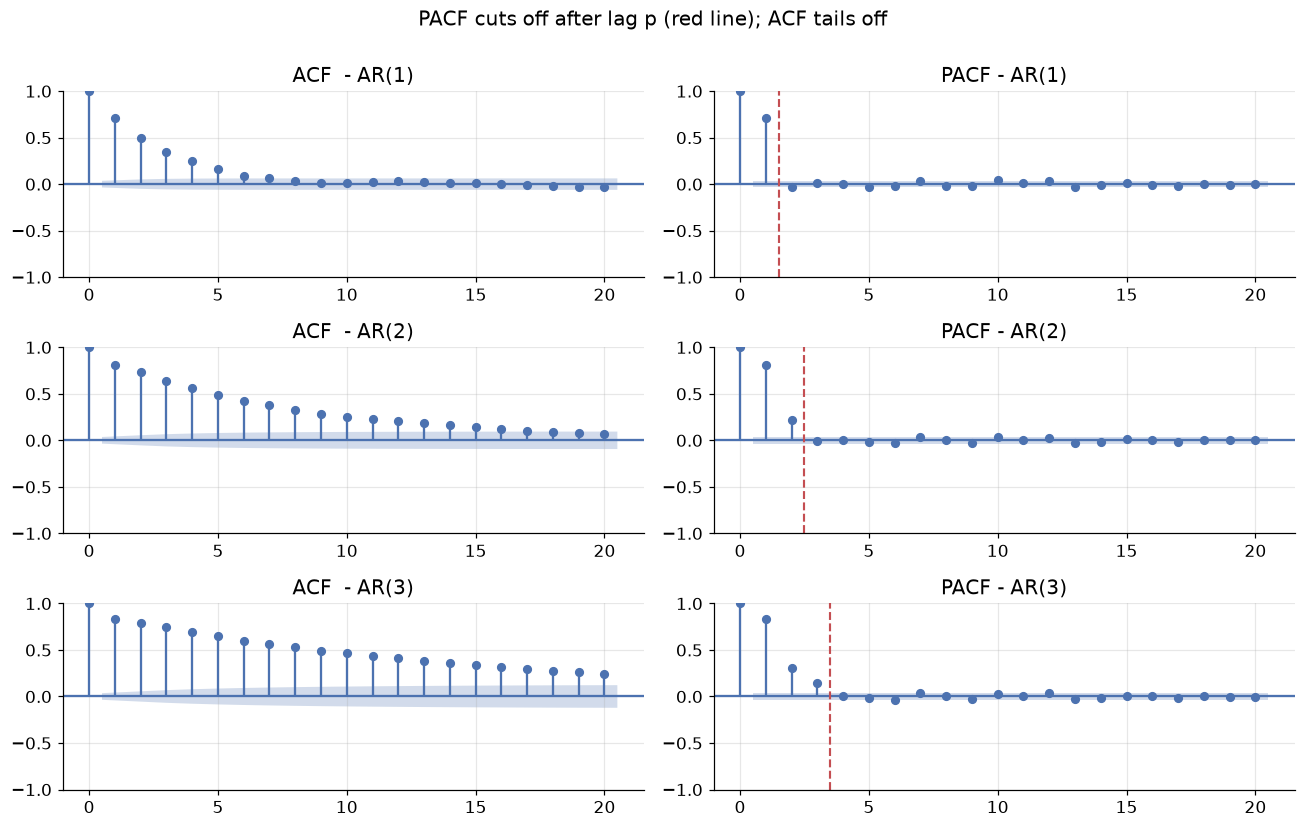

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7.5))
for row, params in enumerate([[0.7], [0.6, 0.25], [0.5, 0.25, 0.15]]):
    series = simulate_arma(params, [], 3000, np.random.default_rng(RANDOM_STATE))
    p = len(params)
    plot_acf(series,  lags=20, ax=axes[row, 0], title=f"ACF  - AR({p})")
    plot_pacf(series, lags=20, ax=axes[row, 1], title=f"PACF - AR({p})", method="ywm")
    axes[row, 1].axvline(p + 0.5, color="C3", ls="--", lw=1.4)
fig.suptitle("PACF cuts off after lag p (red line); ACF tails off", y=1.00)
plt.tight_layout()
plt.show()

Read the right-hand column top to bottom. AR(1): one significant PACF spike, then nothing. AR(2): two
spikes. AR(3): three. **The red dashed line sits at $p + 0.5$ in every row, and the PACF dies exactly
there.** That is how you read $p$ off a plot.

The left column shows the contrasting behaviour: the ACF decays smoothly and never cuts off.

### Recovering the parameters

If the theory is right, fitting an AR model to data we generated ourselves should return the coefficients
we chose. This is the check that separates understanding from hand-waving.

In [4]:
true_ar = [0.6, 0.25]
y_ar = simulate_arma(true_ar, [], 2000, np.random.default_rng(RANDOM_STATE))

fit_ar = ARIMA(y_ar, order=(2, 0, 0), trend="n").fit()

print("AR(2) parameter recovery from 2000 observations\n")
print(f"{'coefficient':<14}{'true':>8}{'estimated':>12}{'std err':>10}")
for i, true_val in enumerate(true_ar, start=1):
    est = fit_ar.params[i - 1]
    se = fit_ar.bse[i - 1]
    print(f"phi_{i:<10}{true_val:>8.2f}{est:>12.3f}{se:>10.3f}")
print(f"\nsigma^2 (noise variance), true 1.0 -> {fit_ar.params[-1]:.3f}")

AR(2) parameter recovery from 2000 observations

coefficient       true   estimated   std err
phi_1             0.60       0.635     0.022
phi_2             0.25       0.221     0.021

sigma^2 (noise variance), true 1.0 -> 1.005


The estimates land close to the truth — within roughly one and a half standard errors, which is ordinary
sampling variation rather than bias. Note that the standard errors are around
0.02 with 2000 observations — precision improves as $\sqrt{n}$, so short series give genuinely uncertain
coefficients. This is worth remembering when you fit a 3-parameter model to 60 monthly observations and
the software reports the numbers to four decimal places anyway.

Internally, statsmodels maximises the likelihood. The classical alternative is the **Yule-Walker
equations**, a linear system relating the $\phi_i$ to the autocorrelations $\rho_k$:

$$\rho_k = \phi_1 \rho_{k-1} + \phi_2 \rho_{k-2} + \dots + \phi_p \rho_{k-p}, \qquad k = 1, \dots, p$$

which in matrix form is $\mathbf{c} = \mathbf{C}\boldsymbol{\Phi}$, solved as
$\boldsymbol{\Phi} = \mathbf{C}^{-1}\mathbf{c}$. It is fast, has a closed form, and is where the "ywm"
method in our PACF calls comes from.

---
## 4. MA(q): regressing on past shocks

A **moving average** model of order $q$ predicts $y_t$ from the last $q$ *random shocks*:

$$y_t = \mu + Z_t + \theta_1 Z_{t-1} + \theta_2 Z_{t-2} + \dots + \theta_q Z_{t-q}$$

or compactly, $y_t = \mu + \theta(B) Z_t$.

First, the terminology warning promised in the introduction: **this is not the rolling mean of Module
10.** Nothing is being averaged over a window. The name is historical and unfortunate; read "MA" as
"a weighted sum of recent shocks" and you will not be confused.

The intuition is about **shocks with a finite lifetime**. An airline suffers a strike in March. March
traffic collapses — that is $Z_{\text{Mar}}$. April is still depressed because rebookings are working
through the system, and May a little; by June the event has washed out completely. An MA(2) model says
exactly that: a shock influences the next two periods and then vanishes.

Contrast this with AR, where the influence of a shock decays *geometrically forever*, never quite
reaching zero. **AR has infinite memory that fades; MA has finite memory that stops.**

### The identification rule for MA

The rules are the mirror image of AR's:

> **The ACF cuts off sharply after lag $q$. The PACF tails off gradually.**

And the reason is direct: $y_t$ and $y_{t-k}$ share a common shock term only when $k \le q$. Beyond that
they have literally no ingredient in common, so their correlation is exactly zero.

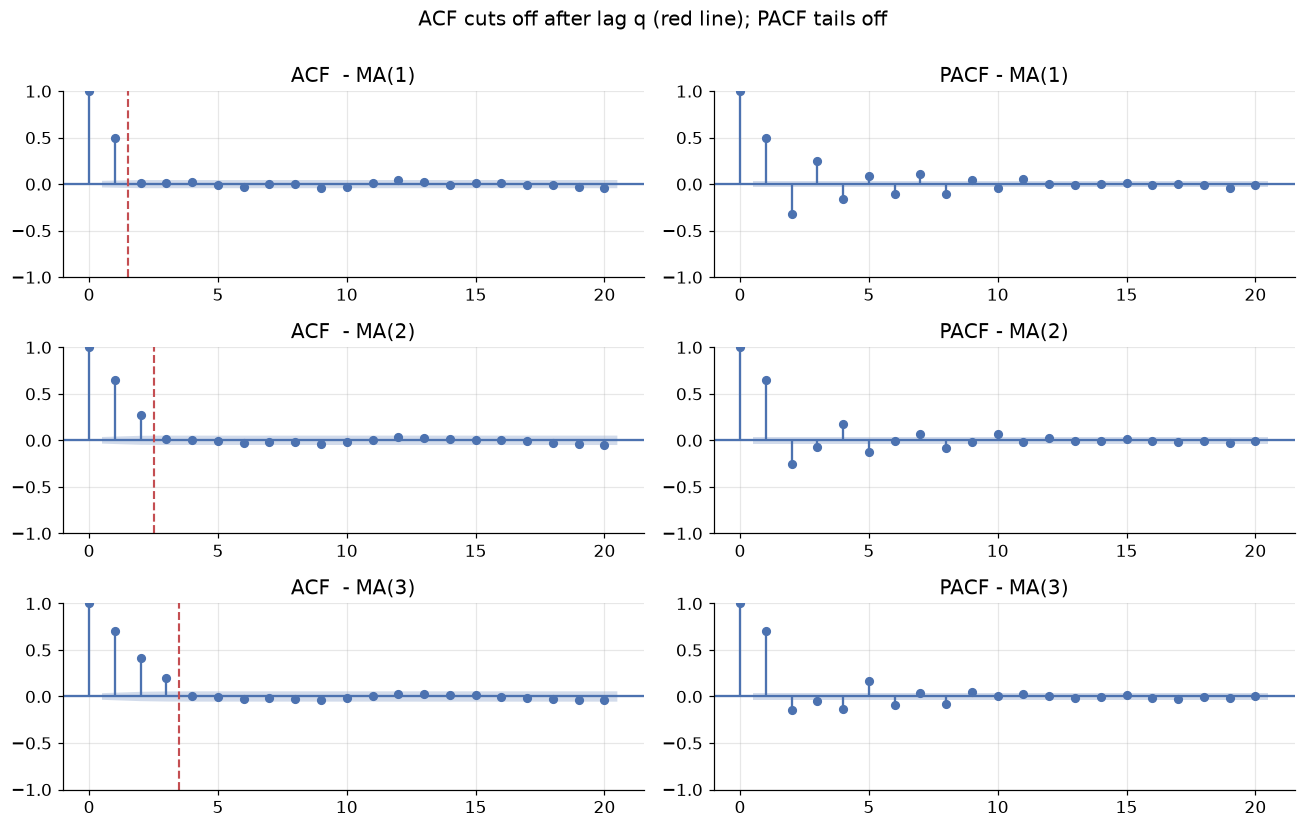

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7.5))
for row, params in enumerate([[0.8], [0.8, 0.5], [0.8, 0.5, 0.4]]):
    series = simulate_arma([], params, 3000, np.random.default_rng(RANDOM_STATE))
    q = len(params)
    plot_acf(series,  lags=20, ax=axes[row, 0], title=f"ACF  - MA({q})")
    plot_pacf(series, lags=20, ax=axes[row, 1], title=f"PACF - MA({q})", method="ywm")
    axes[row, 0].axvline(q + 0.5, color="C3", ls="--", lw=1.4)
fig.suptitle("ACF cuts off after lag q (red line); PACF tails off", y=1.00)
plt.tight_layout()
plt.show()

Now it is the **left** column that cuts off — cleanly at lag 1, 2 and 3 respectively — while the PACF on
the right tails away. Compare this figure with the AR figure in Section 3 and the whole identification
procedure is visible in one glance: **whichever plot cuts off tells you which model you have, and where
it cuts off tells you the order.**

In [6]:
true_ma = [0.8, 0.5]
y_ma = simulate_arma([], true_ma, 2000, np.random.default_rng(RANDOM_STATE))

fit_ma = ARIMA(y_ma, order=(0, 0, 2), trend="n").fit()

print("MA(2) parameter recovery from 2000 observations\n")
print(f"{'coefficient':<14}{'true':>8}{'estimated':>12}{'std err':>10}")
for i, true_val in enumerate(true_ma, start=1):
    print(f"theta_{i:<8}{true_val:>8.2f}{fit_ma.params[i-1]:>12.3f}{fit_ma.bse[i-1]:>10.3f}")

MA(2) parameter recovery from 2000 observations

coefficient       true   estimated   std err
theta_1           0.80       0.840     0.018
theta_2           0.50       0.544     0.019


Recovered again. Note the asymmetry in difficulty, though: an AR model can be fitted by ordinary least
squares because its predictors ($y_{t-1}, \dots$) are *observed*. An MA model cannot, because its
predictors ($Z_{t-1}, \dots$) are **never observed** — they are the model's own errors, which depend on
the parameters you are trying to estimate. MA fitting is therefore inherently iterative, and it is why
MA-heavy models occasionally fail to converge.

---
## 5. ARMA(p,q): both at once

Combine them and you get **ARMA(p,q)**:

$$y_t = c + \underbrace{\sum_{i=1}^{p} \phi_i y_{t-i}}_{\text{past values}} + Z_t +
\underbrace{\sum_{j=1}^{q} \theta_j Z_{t-j}}_{\text{past shocks}}
\qquad\Longleftrightarrow\qquad \phi(B)\, y_t = c + \theta(B)\, Z_t$$

with ARMA(p,0) = AR(p) and ARMA(0,q) = MA(q). Mixed models are common because they are *parsimonious*: a
process needing AR(8) alone might be captured by ARMA(1,1), and fewer parameters means less overfitting
and tighter forecasts.

### The identification table — and its limit

Here is the summary you should memorise, extended to the mixed case:

| Process | ACF | PACF |
|---|---|---|
| **AR(p)** | tails off | **cuts off after lag $p$** |
| **MA(q)** | **cuts off after lag $q$** | tails off |
| **ARMA(p,q)** | tails off | tails off |

Look at the last row carefully, because it is a genuinely bad piece of news. **For a mixed ARMA process
neither plot cuts off**, so the correlogram cannot tell you $p$ and $q$ — it can only suggest *upper
bounds*. Identification by eye stops working exactly where models get interesting.

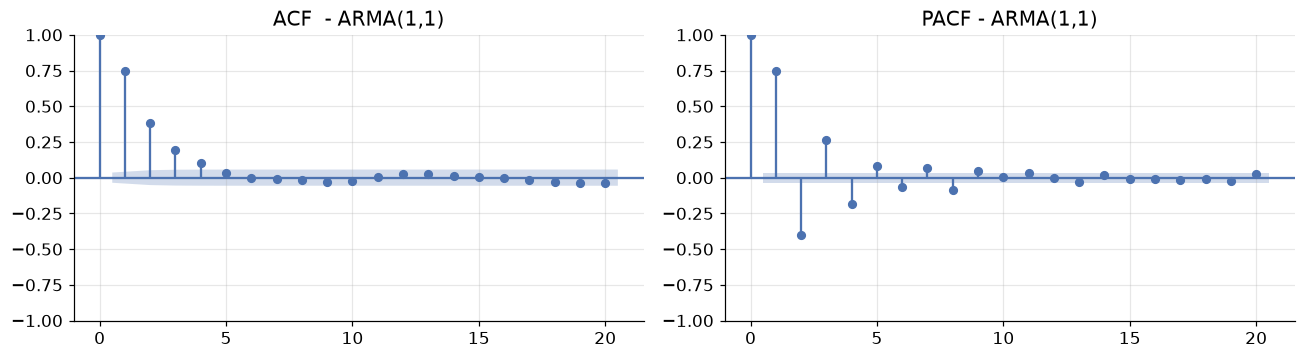

Neither plot cuts off cleanly - the eye cannot read p and q from this.


In [7]:
y_arma = simulate_arma([0.5], [0.7], 3000, np.random.default_rng(RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
plot_acf(y_arma,  lags=20, ax=axes[0], title="ACF  - ARMA(1,1)")
plot_pacf(y_arma, lags=20, ax=axes[1], title="PACF - ARMA(1,1)", method="ywm")
plt.tight_layout()
plt.show()

print("Neither plot cuts off cleanly - the eye cannot read p and q from this.")

Both plots decay. Knowing the truth is ARMA(1,1), you might squint and defend it, but you would equally
defend AR(2) or ARMA(2,1). This is not a failure of your eyesight — it is a real limitation of the
method, and it is precisely why Section 7 replaces eyeballing with a numerical criterion.

The honest workflow is therefore: **use ACF/PACF to bound the search space, then use an information
criterion to choose within it.**

---
## 6. ARIMA(p,d,q): folding in the differencing

ARMA requires stationarity, and Module 10 showed that real series rarely oblige. We already know the fix —
difference the series — and **ARIMA simply makes the number of differences a model parameter.**

Let $y'_t = \nabla^d y_t$. Then ARIMA(p,d,q) says $y'_t$ follows an ARMA(p,q):

$$\phi(B)\, (1-B)^d\, y_t = c + \theta(B)\, Z_t$$

The **I** stands for *integrated*, "integration" being the inverse of differencing — the cumulative
summation that puts a forecast of *changes* back onto the scale of *levels*.

The practical consequence is one you must not get wrong: **fit ARIMA to the original series and let $d$
do the differencing.** If you difference by hand and then fit with $d = 0$, the model will forecast
differences, and undoing that transformation (plus its prediction intervals) becomes your problem. Passing
$d$ makes statsmodels handle both directions for you.

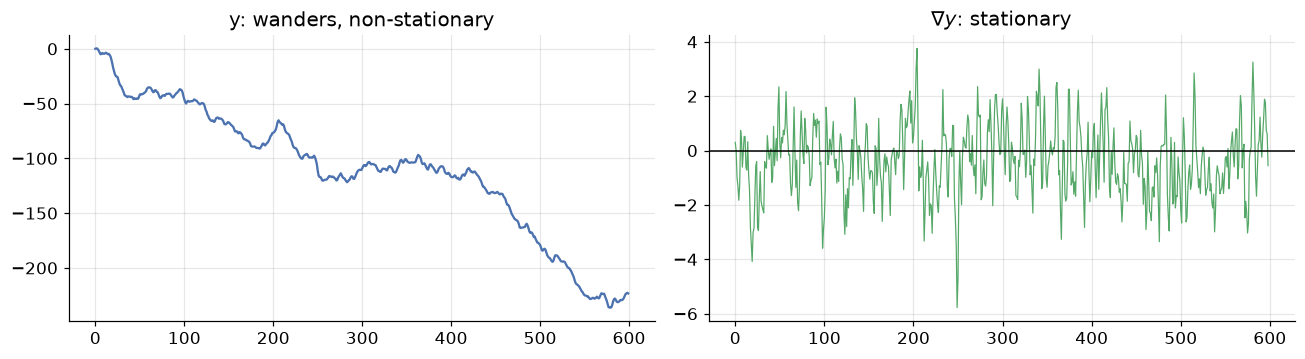

ADF-selected d = 1   (final p-value 0.00000)



Fitted on the ORIGINAL series with d=1:
  phi_1   = 0.514  (true 0.5)
  theta_1 = 0.400  (true 0.4)


In [8]:
# A trended series: cumulative sum of an ARMA(1,1) process -> ARIMA(1,1,1) by construction
y_stat = simulate_arma([0.5], [0.4], 600, np.random.default_rng(7))
y_trend = np.cumsum(y_stat)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(y_trend, color="C0"); axes[0].set_title("y: wanders, non-stationary")
axes[1].plot(np.diff(y_trend), color="C2", lw=0.8)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title(r"$\nabla y$: stationary")
plt.tight_layout()
plt.show()

# How many differences does the ADF test demand?
d, series = 0, y_trend.copy()
while adfuller(series)[1] > 0.05 and d < 3:
    series = np.diff(series)
    d += 1
print(f"ADF-selected d = {d}   (final p-value {adfuller(series)[1]:.5f})")

fit_arima = ARIMA(y_trend, order=(1, d, 1), trend="n").fit()
print(f"\nFitted on the ORIGINAL series with d={d}:")
print(f"  phi_1   = {fit_arima.params[0]:.3f}  (true 0.5)")
print(f"  theta_1 = {fit_arima.params[1]:.3f}  (true 0.4)")

The automatic loop finds $d = 1$, and fitting ARIMA(1,1,1) to the *undifferenced* series recovers both
underlying parameters. That loop is a reasonable way to pick $d$ in practice — though be conservative:
**over-differencing is a real hazard**, and Module 10 gave its signature (an inflated variance and a large
negative spike at lag 1 of the ACF). In practice $d$ is almost always 0, 1, or 2.

---
## 7. Choosing orders: AIC and BIC

Section 5 left us needing a numerical criterion. The obvious idea — pick the model with the best
likelihood — fails immediately, because likelihood *always* improves as you add parameters. It is the
overfitting problem from the Regularization module, in a new costume, and the solution is the same:
**penalise complexity.**

For a model with $K$ parameters fitted to $n$ observations with maximised likelihood $\hat{L}$:

$$\text{AIC} = -2\log \hat{L} + 2K \qquad\qquad \text{BIC} = -2\log \hat{L} + K\log n$$

**Lower is better for both.** The first term rewards fit; the second charges rent per parameter. They
differ only in the rent:

- **AIC** charges $2$ per parameter, flat. It targets *predictive accuracy* and tends to pick slightly
  larger models.
- **BIC** charges $\log n$, which exceeds 2 as soon as $n > 7$ — so for any realistic series BIC is
  **harsher** and prefers smaller models. It targets *finding the true model*.

Neither is universally right. A common practice — which we follow — is to grid-search a small space of
orders and inspect both.

In [9]:
y_search = simulate_arma([0.3, 0.1], [0.5, 0.3], 2500, np.random.default_rng(1000))  # true ARMA(2,2)

rows = []
for p, q in itertools.product(range(4), range(4)):
    try:
        m = ARIMA(y_search, order=(p, 0, q), trend="n").fit()
        rows.append({"p": p, "q": q, "AIC": m.aic, "BIC": m.bic})
    except Exception:
        pass

grid = pd.DataFrame(rows)
print("Best 6 by AIC (true process is ARMA(2,2)):\n")
print(grid.sort_values("AIC").head(6).to_string(index=False))
print(f"\nAIC picks: ARMA({grid.loc[grid.AIC.idxmin(), 'p']}, {grid.loc[grid.AIC.idxmin(), 'q']})")
print(f"BIC picks: ARMA({grid.loc[grid.BIC.idxmin(), 'p']}, {grid.loc[grid.BIC.idxmin(), 'q']})")

Best 6 by AIC (true process is ARMA(2,2)):

 p  q         AIC         BIC
 1  3 6995.655298 7024.775528
 2  2 6996.032699 7025.152929
 2  3 6997.641829 7032.586105
 3  2 6997.813652 7032.757928
 1  2 6998.040823 7021.337007
 3  3 6999.391804 7040.160126

AIC picks: ARMA(1, 3)
BIC picks: ARMA(1, 2)


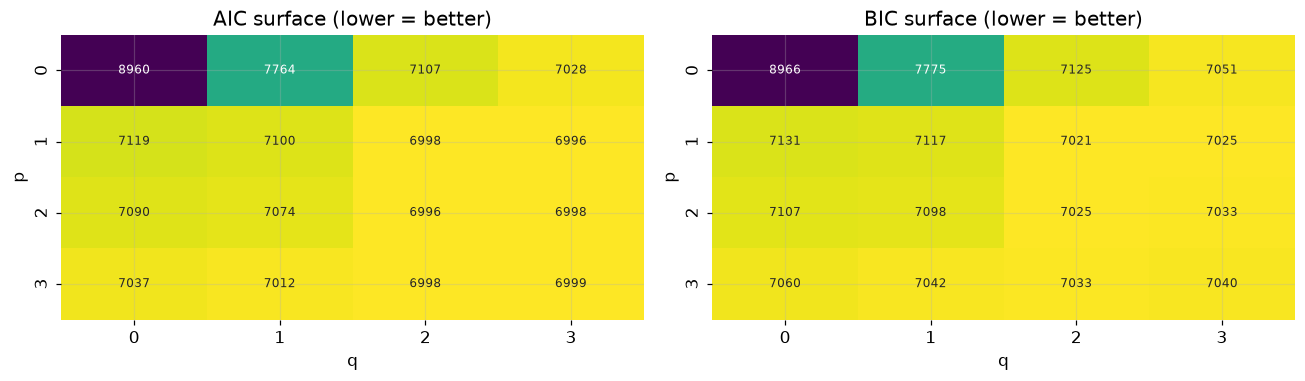

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, crit in zip(axes, ["AIC", "BIC"]):
    pivot = grid.pivot(index="p", columns="q", values=crit)
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis_r", ax=ax, cbar=False,
                annot_kws={"size": 8})
    ax.set_title(f"{crit} surface (lower = better)")
plt.tight_layout()
plt.show()

**Neither criterion picked the true model, and you should not gloss over that.** The data really was
ARMA(2,2), 2500 observations of it; AIC chose ARMA(1,3) and BIC chose ARMA(1,2). The true model came
*second* on AIC — by a margin of about 0.4 units.

That is the lesson, not a bug. Different $(p,q)$ combinations can describe almost the same
autocorrelation structure, so the criterion surface is nearly flat across a whole neighbourhood of
models, and which one wins is decided by sampling noise. The heatmaps make this visible: a broad basin of
near-equivalent models rather than one sharp peak.

The practical rules that follow are:

- **Differences of 1–2 units are noise.** Treat everything within a few units of the best as tied.
- **Break ties by parsimony** — prefer the smaller model, since it will generalise better and is easier
  to interpret.
- **Do not report the selected orders as "the truth".** They are one reasonable description among
  several, chosen by a criterion that is itself an estimate.

Two cautions before you automate this:

- **AIC and BIC are only comparable between models fitted to the same data with the same $d$.**
  Differencing changes the number of observations and hence the likelihood, so an ARIMA(1,1,1) AIC cannot
  be compared with an ARIMA(1,0,1) AIC. Choose $d$ first, by stationarity testing; then search $p$ and $q$.
- **They are in-sample criteria.** They estimate out-of-sample error rather than measuring it. The real
  verdict is still a held-out test set — which is why we keep one.

---
## 8. SARIMA: adding the seasons

Air Passengers has a strong annual cycle, and nothing so far can represent it. An ARIMA model would need
$p \ge 12$ to reach back a year — twelve parameters to express one idea.

**SARIMA** solves this by bolting a *second, seasonal* set of terms onto the model, operating at lag $s$
instead of lag 1:

$$\underbrace{\Phi_P(B^s)\, \phi_p(B)}_{\text{AR: seasonal} \times \text{non-seasonal}}
\underbrace{\nabla_s^D \nabla^d}_{\text{differencing}} y_t =
\underbrace{\Theta_Q(B^s)\, \theta_q(B)}_{\text{MA: seasonal} \times \text{non-seasonal}} Z_t$$

written **SARIMA$(p,d,q)(P,D,Q)_s$**. The uppercase orders are the seasonal counterparts of the lowercase
ones, and everything is in terms of $B^s$ — so $\Phi_1(B^{12})$ links this month to the same month *last
year*.

The two sets **multiply** rather than add, which is what makes the model compact. Expanding
SARIMA$(1,0,1)(1,0,1)_{12}$ gives

$$y_t = \phi y_{t-1} + \Phi y_{t-12} - \Phi\phi\, y_{t-13} + Z_t + \theta Z_{t-1} + \Theta Z_{t-12} +
\Theta\theta\, Z_{t-13}$$

Look at the $y_{t-13}$ term. Nobody put it there — it *fell out of the multiplication*, and it says
something sensible: if this month depends on last month, and on this month a year ago, then it also
depends on last month a year ago. Four parameters generate seven terms of structure.

### Reading seasonal orders

The identification rules carry over, applied **at multiples of $s$**:

| Seasonal process | ACF at lags $s, 2s, 3s\dots$ | PACF at lags $s, 2s, 3s\dots$ |
|---|---|---|
| **AR$(P)_s$** | tails off | **cuts off after lag $Ps$** |
| **MA$(Q)_s$** | **cuts off after lag $Qs$** | tails off |

So you read the plot **twice**: look at lags $1, 2, \dots, s-1$ for the non-seasonal orders $p, q$, and at
lags $s, 2s, 3s$ for the seasonal orders $P, Q$.

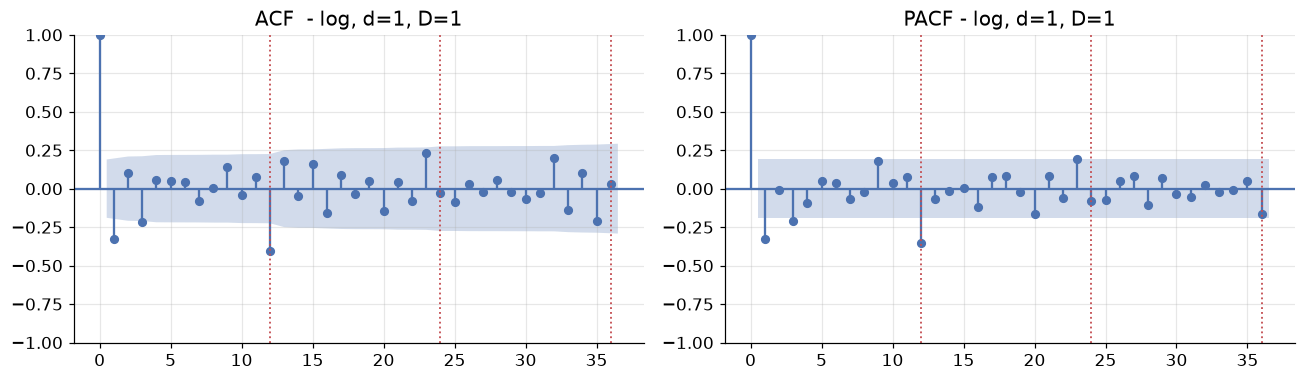

ADF p-value after d=1, D=1: 0.00139


In [11]:
log_train = np.log(train)                              # multiplicative -> additive (Module 10)
stationary = log_train.diff().diff(12).dropna()        # d=1, D=1

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_acf(stationary,  lags=36, ax=axes[0], title="ACF  - log, d=1, D=1")
plot_pacf(stationary, lags=36, ax=axes[1], title="PACF - log, d=1, D=1", method="ywm")
for ax in axes:
    for lag in (12, 24, 36):
        ax.axvline(lag, color="C3", ls=":", lw=1.2)
plt.tight_layout()
plt.show()

print(f"ADF p-value after d=1, D=1: {adfuller(stationary)[1]:.5f}")

Read this plot the way Box and Jenkins did in 1970.

- **Non-seasonal part (low lags).** The ACF has one clear significant spike at lag 1, then falls inside
  the band. That is the MA cut-off signature: $q = 1$, $p = 0$.
- **Seasonal part (dotted red lines at 12, 24, 36).** A large spike at lag 12, and essentially nothing at
  24 or 36. Same signature at the seasonal frequency: $Q = 1$, $P = 0$.

Together the plot proposes **SARIMA$(0,1,1)(0,1,1)_{12}$** on the logged series — which is famous enough
to have its own name, the **airline model**, precisely because Box and Jenkins identified it on *this
dataset*. Let us see whether an exhaustive search agrees with the eyeball.

In [12]:
results = []
for p, q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(log_train, order=(p, 1, q), seasonal_order=(P, 1, Q, 12)).fit(disp=False)
        results.append({"order": (p, 1, q), "seasonal": (P, 1, Q, 12),
                        "AIC": m.aic, "BIC": m.bic, "params": len(m.params)})
    except Exception:
        pass

search = pd.DataFrame(results).sort_values("AIC")
print(f"Searched {len(search)} models. Top 6 by AIC:\n")
print(search.head(6).to_string(index=False))

Searched 36 models. Top 6 by AIC:

    order      seasonal         AIC         BIC  params
(0, 1, 1) (0, 1, 1, 12) -389.009724 -380.991238       3
(1, 1, 0) (0, 1, 1, 12) -388.643057 -380.624570       3
(0, 1, 1) (1, 1, 1, 12) -387.220007 -376.528692       4
(0, 1, 2) (0, 1, 1, 12) -387.065411 -376.374096       4
(1, 1, 0) (1, 1, 1, 12) -386.774772 -376.083457       4
(1, 1, 1) (0, 1, 1, 12) -386.674591 -375.983276       4


The search agrees with the correlogram: **SARIMA$(0,1,1)(0,1,1)_{12}$ is best on AIC — and on BIC too**,
which is notable, since BIC's harsher penalty often disagrees with AIC. When the visual identification,
AIC and BIC all converge on the same model, you can be reasonably confident in it.

Notice also how little separates the top few models — a couple of AIC units across quite different order
combinations. The winner is among the *smallest* of that group (three parameters), so parsimony and the
criteria point the same way.

In [13]:
best = search.iloc[0]
model = SARIMAX(log_train, order=best["order"], seasonal_order=best["seasonal"]).fit(disp=False)
print(model.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3422      0.087     -3.922      0.000      -0.513      -0.171
ma.S.L12      -0.5405      0.105     -5.158      0.000      -0.746      -0.335
sigma2         0.0014      0.000      7.869      0.000       0.001       0.002


Both coefficients are strongly significant ($p < 0.001$) and both are **negative**, which has a clean
interpretation. $\theta_1 \approx -0.34$ says a positive shock this month is partly *corrected* next
month; $\Theta_{12} \approx -0.54$ says the same about the shock from twelve months ago. The series
overshoots and pulls back, at both timescales.

The coefficients you would have got from the deprecated `sm.tsa.ARMA` API differ in sign convention from
the modern one — one more reason to keep to a single, current API.

---
## 9. Residual diagnostics

**This is the step people skip, and it is the step that catches broken models.**

The logic is the one Module 10 established: a model's job is to extract all forecastable structure, so
whatever remains must be *unforecastable* — white noise. Concretely, residuals should be

1. **uncorrelated** — any leftover autocorrelation is signal you failed to model;
2. **zero-mean** — otherwise the forecast is biased;
3. **constant-variance** and roughly **normal** — needed for the prediction intervals to be honest.

Requirement 1 is essential; 3 matters mainly for the intervals rather than the point forecast.

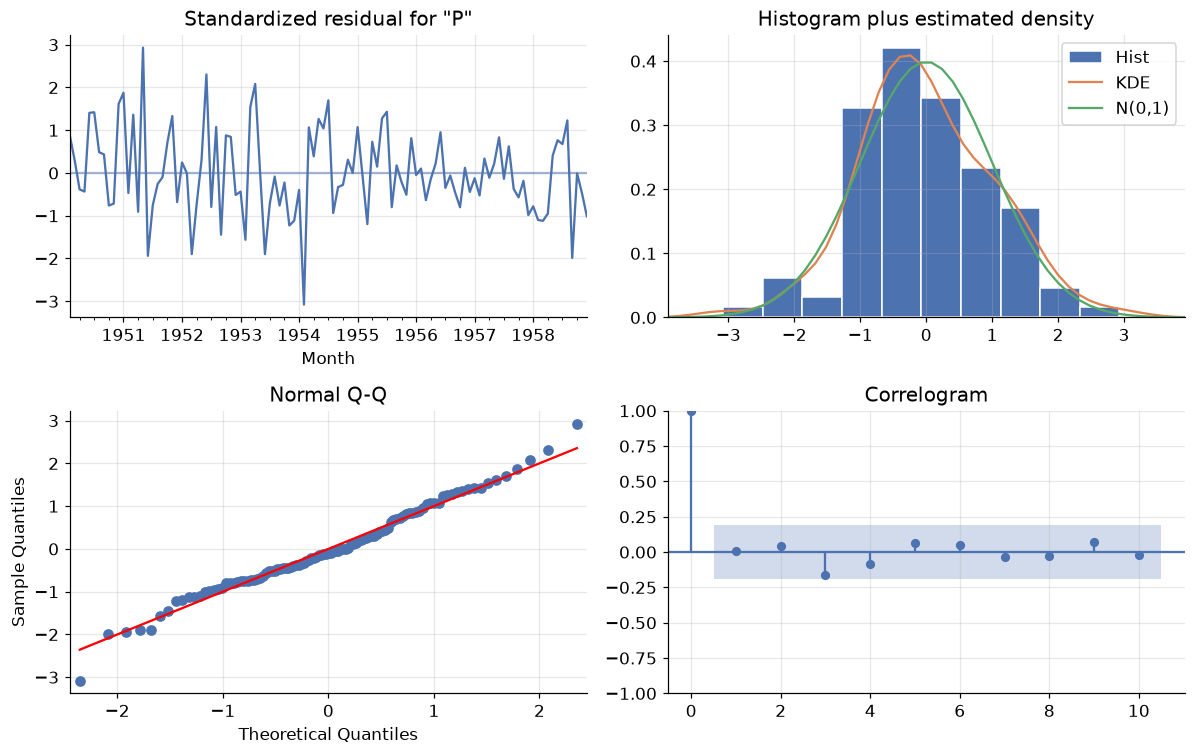

In [14]:
fig = model.plot_diagnostics(figsize=(11, 7))
plt.tight_layout()
plt.show()

`plot_diagnostics` gives four panels at once:

- **Top-left, standardised residuals** — should look like noise around zero with no changing spread.
- **Top-right, histogram + density** — the orange KDE should track the green $N(0,1)$ reference.
- **Bottom-left, Normal Q-Q** — points on the red line mean normality; curvature at the ends means heavy
  tails.
- **Bottom-right, correlogram** — **the most important panel.** Every spike should sit inside the band.

### The Ljung-Box test

The correlogram is a judgement call over many lags, and with 20 spikes at a 95% band you *expect* one to
poke out. The **Ljung-Box** test formalises it by asking whether the first $h$ autocorrelations are
*jointly* zero:

$$Q = n(n+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{n-k} \;\sim\; \chi^2_{h}$$

Its null hypothesis is **"the residuals are independent"** — so here, unusually, a **large p-value is the
good outcome**.

In [15]:
resid = model.resid[13:]           # drop the first d + D*s = 13 values lost to differencing
lb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], return_df=True)
lb["verdict"] = np.where(lb["lb_pvalue"] > 0.05, "white noise OK", "STRUCTURE LEFT")
print("Ljung-Box  (H0 = residuals independent, so we WANT p > 0.05)\n")
print(lb.round(4).to_string())

print(f"\nMean residual: {resid.mean():+.5f}  (log scale; want ~0)")
print(f"Residual std:  {resid.std():.5f}")

Ljung-Box  (H0 = residuals independent, so we WANT p > 0.05)

    lb_stat  lb_pvalue         verdict
6    4.8820     0.5590  white noise OK
12   6.0738     0.9123  white noise OK
18  10.5067     0.9141  white noise OK
24  17.9889     0.8035  white noise OK

Mean residual: +0.00028  (log scale; want ~0)
Residual std:  0.03857


Every p-value is comfortably above 0.05 — at lag 12 it is around 0.91 — so we cannot reject independence
at any horizon tested. Combined with a mean residual of essentially zero, the model passes.

**This is the moment you are allowed to forecast.** Had any p-value come in below 0.05, the correct
response would be to return to identification with the residual ACF as the clue: a leftover spike at lag
12 means the seasonal orders are wrong, one at lag 1 means the non-seasonal orders are.

---
## 10. Forecasting Air Passengers

Now we spend the model. Three things to get right: forecast on the **log** scale the model was fitted on,
**back-transform** with `np.exp`, and carry the **prediction intervals** through the same transformation.

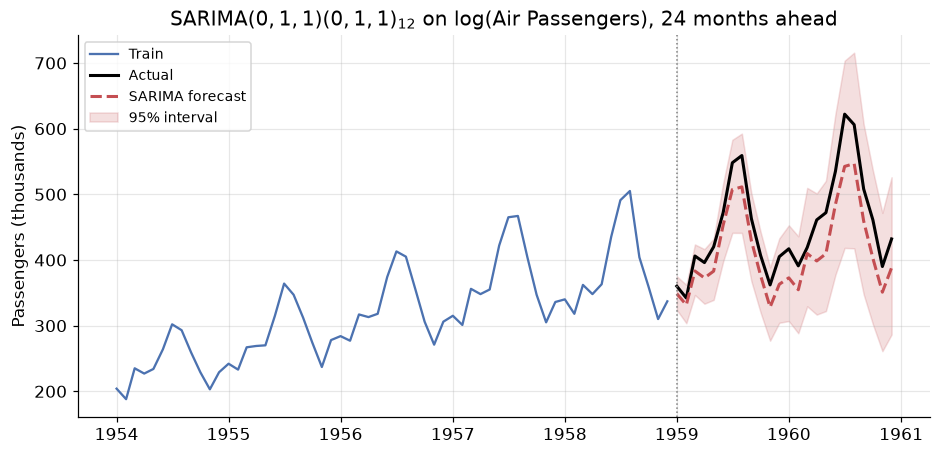

Actual values inside the 95% interval: 100%


In [16]:
fc = model.get_forecast(steps=TEST_MONTHS)
pred_log = fc.predicted_mean
ci_log = fc.conf_int(alpha=0.05)

# Back-transform: exp() maps the log-scale interval to a (correctly asymmetric) interval on the original scale
pred = np.exp(pred_log)
lower, upper = np.exp(ci_log.iloc[:, 0]), np.exp(ci_log.iloc[:, 1])
pred.index = lower.index = upper.index = test.index

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train[-60:], color="C0", label="Train")
ax.plot(test, color="black", lw=2, label="Actual")
ax.plot(pred, color="C3", lw=2, ls="--", label="SARIMA forecast")
ax.fill_between(test.index, lower, upper, color="C3", alpha=0.18, label="95% interval")
ax.axvline(test.index[0], color="grey", ls=":", lw=1)
ax.set_title(r"SARIMA$(0,1,1)(0,1,1)_{12}$ on log(Air Passengers), 24 months ahead")
ax.set_ylabel("Passengers (thousands)")
ax.legend(fontsize=9)
plt.show()

coverage = ((test >= lower) & (test <= upper)).mean()
print(f"Actual values inside the 95% interval: {coverage:.0%}")

The forecast reproduces both the growth and the seasonal shape, and the interval widens with the horizon —
exactly as it should, since uncertainty compounds. Interval **coverage** is the diagnostic to check here:
a nominal 95% interval that captures far less than 95% of actuals is overconfident, and the model's
uncertainty estimates cannot be trusted even if the point forecasts look fine.

Now the comparison that this entire section of the course has been building towards.

In [17]:
m_ = 12
h = len(test)
baselines = {
    "Mean":           pd.Series(train.mean(), index=test.index),
    "Naive":          pd.Series(train.iloc[-1], index=test.index),
    "Seasonal naive": pd.Series(train.iloc[-m_:].values[np.arange(h) % m_], index=test.index),
    "Drift":          pd.Series(train.iloc[-1] + np.arange(1, h + 1)
                                * (train.iloc[-1] - train.iloc[0]) / (len(train) - 1), index=test.index),
    "SARIMA(0,1,1)(0,1,1)12": pred,
}

# Module 11's winner, refitted here so all three modules appear in one table
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=12).fit()
baselines["Holt-Winters (mult)"] = hw.forecast(TEST_MONTHS)

table = pd.DataFrame({k: evaluate(test, v, train) for k, v in baselines.items()}).T
table = table.sort_values("MASE")
print(table.round(2).to_string())

sn_mae = table.loc["Seasonal naive", "MAE"]
sar_mae = table.loc["SARIMA(0,1,1)(0,1,1)12", "MAE"]
hw_mae = table.loc["Holt-Winters (mult)", "MAE"]
print(f"\nSARIMA reduces MAE vs the best baseline (seasonal naive) by {(1 - sar_mae/sn_mae):.0%}")
print(f"Holt-Winters beats SARIMA by a further {(1 - hw_mae/sar_mae):.0%}")

                           MAE    RMSE   MAPE  MASE
Holt-Winters (mult)      28.98   32.49   6.39  1.01
SARIMA(0,1,1)(0,1,1)12   39.45   43.19   8.52  1.38
Seasonal naive           71.25   76.99  15.52  2.49
Drift                    91.62  115.70  18.41  3.21
Naive                   115.25  137.33  23.58  4.03
Mean                    206.34  219.44  44.23  7.22

SARIMA reduces MAE vs the best baseline (seasonal naive) by 45%
Holt-Winters beats SARIMA by a further 27%


Two things to take from this table, and the second one matters more than the first.

**SARIMA comprehensively beats the baselines.** It roughly halves the MAE of seasonal naive — the
benchmark Module 10 warned was genuinely hard to beat — and it does so for the reason we designed it to:
$d=1$ models the growth that seasonal naive ignored, while $D=1$ models the season that drift ignored.

**And Holt-Winters, from Module 11, beats SARIMA.** That is not a mistake, and it is not an argument that
one module was wasted. It is the single most important empirical fact in this section of the course, so
let us state it plainly: **the more sophisticated, more famous, harder-to-fit model lost.**

Why? Air Passengers is almost a textbook illustration of what exponential smoothing is built for — a
smooth trend with a stable multiplicative seasonal profile, and nothing else going on. Holt-Winters models
exactly that structure directly, with three interpretable components. SARIMA has to reach the same place
through differencing and autocorrelation, which is a more roundabout route to a shape that was already
obvious. In the M-competitions — the large-scale empirical forecasting contests that settled a lot of
these arguments — simple exponential smoothing methods beat ARIMA on a great many real series, and this
is a small replication of that result.

The correct conclusion is *not* "ARIMA is bad". ARIMA earns its keep where the structure is genuinely
autocorrelative rather than componential, where you need exogenous regressors (Section 11), or where you
want the statistical apparatus — significance tests, information criteria, principled prediction
intervals — that the Box-Jenkins framework provides and exponential smoothing does not. The conclusion is:

> **Model complexity is not a proxy for model quality. Fit both, hold out a test set, and let it decide.**

That is the arc of all three modules. Module 10 built the diagnosis and the benchmark; Modules 11 and 12
built competing models; and the ranking between them was settled by data no model had seen, not by which
one had the more impressive derivation.

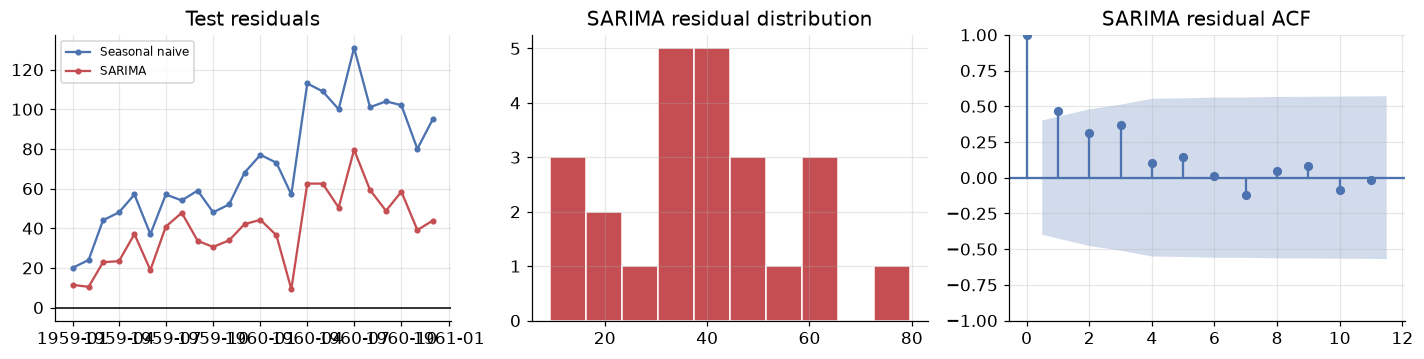

Mean test residual - seasonal naive:  +71.25
Mean test residual - SARIMA:          +39.45


In [18]:
sarima_resid = test - pred
sn_resid = test - baselines["Seasonal naive"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(sn_resid, color="C0", marker="o", ms=3, label="Seasonal naive")
axes[0].plot(sarima_resid, color="C3", marker="o", ms=3, label="SARIMA")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Test residuals"); axes[0].legend(fontsize=8)
axes[1].hist(sarima_resid, bins=10, color="C3", edgecolor="white")
axes[1].set_title("SARIMA residual distribution")
plot_acf(sarima_resid, lags=11, ax=axes[2], title="SARIMA residual ACF")
plt.tight_layout()
plt.show()

print(f"Mean test residual - seasonal naive: {sn_resid.mean():+7.2f}")
print(f"Mean test residual - SARIMA:         {sarima_resid.mean():+7.2f}")

Read the printed means carefully, because they say something more interesting than "SARIMA won".

For **both** methods the mean test residual is *equal to the MAE* — which can only happen if **every
single residual is positive**. Seasonal naive under-forecasts all 24 months, and so does SARIMA. The bias
is smaller (about $+39$ versus $+71$), but it has not been eliminated.

So the Module 10 diagnosis was only half right. Adding a trend component shrank the under-forecast without
removing it, and the reason is visible in the forecast plot of Section 10: 1959–60 grew *faster* than the
1949–58 average that the model extrapolated. A model fitted on a decade of history cannot know that the
last two years accelerate; it is not mis-specified so much as asked to predict a change in regime.

This is the honest limit of the exercise, and worth sitting with. In-sample residual diagnostics
(Section 9) were clean — Ljung-Box passed at every lag — yet the *out-of-sample* residuals are visibly
biased. **Passing residual diagnostics means the model has extracted the structure that was present in
the training data. It does not promise the future will keep obeying it.** That gap is exactly why we hold
out a test set instead of trusting AIC and Ljung-Box alone.

---
## 11. SARIMAX: bringing in outside information

Everything so far has been **univariate** — the series explained purely by its own history. Often you know
more: promotions drive sales, temperature drives electricity demand, holidays drive traffic.

The distinction is between two kinds of variable:

- **Endogenous** ($y_t$) — the variable the model explains, determined *inside* the system.
- **Exogenous** ($u_t$) — an input determined *outside* the system, taken as given.

The **X** in SARIMAX adds exogenous regressors as an ordinary linear term:

$$\Phi_P(B^s)\phi_p(B)\, \nabla_s^D \nabla^d y_t = \boldsymbol{\tau}^\top \mathbf{u}_t +
\Theta_Q(B^s)\theta_q(B)\, Z_t$$

The model becomes "regression with ARIMA errors": a regression on $\mathbf{u}_t$, where the leftover
correlated structure is handled by the SARIMA machinery instead of being wrongly assumed independent.

To demonstrate it we need an exogenous variable. Air Passengers has no natural one, so we use a
**deterministic calendar feature** — a summer indicator — which is legitimate because the calendar is
genuinely known in advance.

In [19]:
def summer_flag(index):
    """1 for the peak travel months, 0 otherwise. Known in advance for any future date."""
    return pd.DataFrame({"summer": index.month.isin([6, 7, 8]).astype(float)}, index=index)

exog_train, exog_test = summer_flag(train.index), summer_flag(test.index)

model_x = SARIMAX(log_train, exog=exog_train,
                  order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print(model_x.summary().tables[1])

pred_x = np.exp(model_x.get_forecast(steps=TEST_MONTHS, exog=exog_test).predicted_mean)
pred_x.index = test.index

comparison = pd.DataFrame({
    "SARIMA (no exog)": evaluate(test, pred, train),
    "SARIMAX (+summer)": evaluate(test, pred_x, train),
}).T
print("\n" + comparison.round(2).to_string())
print(f"\nAIC  without exog: {model.aic:.2f}\nAIC  with exog:    {model_x.aic:.2f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
summer      9.786e-11   4.63e-11      2.114      0.035    7.13e-12    1.89e-10
ma.L1         -0.3422      0.087     -3.920      0.000      -0.513      -0.171
ma.S.L12      -0.5404      0.105     -5.154      0.000      -0.746      -0.335
sigma2         0.0014      0.000      7.863      0.000       0.001       0.002

                     MAE   RMSE  MAPE  MASE
SARIMA (no exog)   39.45  43.19  8.52  1.38
SARIMAX (+summer)  39.46  43.19  8.52  1.38

AIC  without exog: -389.01
AIC  with exog:    -387.01


This result is worth more than a success would have been. The summer indicator adds essentially nothing —
the metrics barely move and AIC gets *worse* once the extra parameter is charged for.

The reason is that the information is **already in the model**. The seasonal terms $(0,1,1)_{12}$ have
learned the entire monthly profile from the data, and "it is summer" is a strictly poorer description of
that profile than the twelve-month pattern SARIMA already holds. The exogenous variable is redundant.

The lesson generalises: **exogenous variables help only when they carry information the series' own
history does not.** A promotion calendar, a competitor's price change, a policy shift — those are genuinely
external. Anything that recurs on a fixed calendar cycle is already covered by the seasonal terms. When
you do use exogenous variables, remember the practical catch: to forecast $h$ steps ahead you need
$\mathbf{u}_t$ for those future periods, so either it is known in advance (calendars, holidays) or you must
forecast it too — and its error then propagates into yours.

---
## 12. Your turn

Add cells below each exercise. Exercises 4 and 5 consolidate the big ideas.

**Exercise 1 — Feel the sign convention.**
Simulate $y_t = 0.8y_{t-1} + Z_t$ correctly (`ar=[1, -0.8]`), then repeat with the sign mistake
(`ar=[1, 0.8]`). Plot both and compare their ACFs. What process did the buggy call actually generate, and
why does nothing raise an error?

**Exercise 2 — Identification drill.**
Write a function that takes a series, plots its ACF and PACF, and prints your suggested $(p, q)$. Test it
on five simulated processes whose orders you choose but do not reveal until after you have read the
plots. How often does the eyeball agree with an AIC grid search? Where does it fail — and does the
failure pattern match the ARMA warning in Section 5?

**Exercise 3 — AIC versus BIC.**
Run the Section 7 grid search on ARMA(2,2) data at $n = 200$, $n = 1000$ and $n = 5000$. Record which
orders AIC and BIC each select at each size. BIC's penalty grows with $\log n$ — does it become *more*
or *less* likely to find the true model as $n$ grows, and does AIC over-select as theory predicts?

**Exercise 4 — Break the model, then read the residuals.**
Deliberately fit the wrong model to Air Passengers: SARIMA$(0,1,1)(0,0,0)_{12}$ — that is, no seasonal
terms. Run the full diagnostic suite. Which Ljung-Box lags fail, and where exactly are the spikes in the
residual ACF? Show how those spikes would have told you the seasonal orders were missing even without
knowing the answer.

**Exercise 5 — A genuinely useful exogenous variable.**
Section 11 failed because the summer flag was redundant. Construct one that is not: split Air Passengers
at 1955 and add an exogenous step variable marking the later era (a crude proxy for the arrival of jet
aircraft). Does it improve AIC or the test metrics? Then argue, in a few sentences, whether this is a
legitimate feature or a form of hindsight that would be unavailable in a real forecasting setting.

---
## 13. If you remember nothing else

1. **ARIMA models autocorrelation, not components.** **AR** regresses on past *values* (infinite fading
   memory), **MA** on past *shocks* (finite memory that stops dead), **I** is the differencing from
   Module 10 promoted to a parameter. "MA" here has nothing to do with a rolling mean.

2. **The correlogram identifies the model — up to a point.** AR(p): **PACF cuts off at $p$**. MA(q):
   **ACF cuts off at $q$**. Mixed ARMA: *neither* cuts off, so the plots give only upper bounds and you
   must fall back on an information criterion.

3. **SARIMA$(p,d,q)(P,D,Q)_s$ multiplies a seasonal model onto the non-seasonal one.** Read the low lags
   for $p, q$ and the lags at multiples of $s$ for $P, Q$. The multiplication generates cross terms (like
   $y_{t-13}$) for free, which is why so few parameters go so far.

4. **AIC and BIC trade fit against complexity** ($-2\log\hat{L}$ plus $2K$ or $K\log n$). Lower is better;
   BIC is harsher and prefers smaller models. Compare only across models with the **same $d$ on the same
   data**, and treat differences of 1–2 units as ties broken by parsimony.

5. **Residual diagnostics are not optional.** Uncorrelated, zero-mean, roughly normal residuals are the
   licence to forecast. **Ljung-Box** tests them jointly, and here a **large p-value is the good
   outcome**. Structure left in the residual ACF tells you *which* order to fix — a lag-$s$ spike means
   seasonal, a lag-1 spike means non-seasonal.

6. **Follow the Box-Jenkins loop and it works.** On Air Passengers, visual identification, AIC and BIC all
   converged on SARIMA$(0,1,1)(0,1,1)_{12}$ — the airline model — whose residuals passed every check and
   which cut the best baseline's error roughly in half on data it had never seen. But its *test*
   residuals were still all positive: clean in-sample diagnostics prove the model captured the structure
   in the training data, not that the future will keep obeying it. Hold out a test set regardless.

7. **Exogenous variables (the X) help only when they add information the series' own history lacks.** A
   summer flag added nothing because the seasonal terms already knew. And any exogenous variable must be
   *available for the future periods you forecast*.

8. **Holt-Winters beat SARIMA on this series.** The simpler, older, componential model won because the
   data's structure (smooth trend, stable multiplicative season) is exactly what it represents directly.
   Sophistication is not quality. Fit the simple model and the complex one, score both on held-out data,
   and prefer the winner — not the one with the longer derivation.

---
## 14. Further reading and glossary

### Further reading

- Hyndman & Athanasopoulos, [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/arima.html),
  Chapter 9 — the clearest treatment of ARIMA in print, free online, with excellent ACF/PACF intuition.
- Box, Jenkins, Reinsel & Ljung, *Time Series Analysis: Forecasting and Control* — the original
  methodology. The airline model of Section 8 comes from this book, fitted to this dataset.
- Shumway & Stoffer, [*Time Series Analysis and Its Applications*](https://www.stat.pitt.edu/stoffer/tsa4/)
  — the standard graduate text; Chapter 3 covers ARMA and SARIMA with full derivations.
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
  — the current API, including exogenous regressors and the state-space machinery underneath.
- [`pmdarima`'s `auto_arima`](https://alkaline-ml.com/pmdarima/) — an automated stepwise search that
  packages Sections 7 and 8 into one call. Useful once you can do it by hand; misleading before.

### Glossary

| Term | Meaning |
|---|---|
| **Backshift operator $B$** | $B y_t = y_{t-1}$; makes $\nabla^d = (1-B)^d$ |
| **AR(p)** | Autoregressive: $y_t$ is a linear function of its own $p$ past values |
| **MA(q)** | Moving average: $y_t$ is a linear function of the last $q$ shocks (not a rolling mean) |
| **ARMA(p,q)** | Both, on a stationary series |
| **ARIMA(p,d,q)** | ARMA applied after $d$ differences |
| **SARIMA$(p,d,q)(P,D,Q)_s$** | ARIMA times a seasonal ARIMA operating at lag $s$ |
| **SARIMAX** | SARIMA plus exogenous regressors |
| **$\phi_i$ / $\theta_j$** | AR / MA coefficients (non-seasonal); $\Phi$, $\Theta$ seasonal |
| **White noise $Z_t$** | Independent zero-mean constant-variance shocks; the unforecastable part |
| **Random walk** | AR(1) with $\phi_1 = 1$; the unit-root case |
| **Cut off / tail off** | Drops abruptly to zero after a lag / decays gradually — the identification signature |
| **Yule-Walker equations** | Linear system relating AR coefficients to autocorrelations |
| **AIC / BIC** | $-2\log\hat{L} + 2K$ / $+K\log n$; lower is better, BIC is harsher |
| **Ljung-Box test** | Joint test that the first $h$ residual autocorrelations are zero; want p > 0.05 |
| **Airline model** | SARIMA$(0,1,1)(0,1,1)_{12}$ on a logged series; Box & Jenkins' fit to this data |
| **Endogenous / exogenous** | Explained by the model / supplied from outside as a given input |
| **Prediction interval** | Range expected to contain the future value with stated probability; widens with horizon |
| **Box-Jenkins methodology** | Identify → estimate → check residuals → forecast, looping on failure |